# 🛡️ Cybersecurity Threat Detection - Advanced ML Training

This notebook demonstrates advanced machine learning techniques for cybersecurity threat detection using multiple algorithms and real-world datasets.

## 📊 What we'll cover:
- **Dataset Loading & Preprocessing** - Multiple cybersecurity datasets
- **Feature Engineering** - Advanced feature extraction and selection
- **Model Training** - Random Forest, XGBoost, Neural Networks, Deep Learning
- **Model Evaluation** - Comprehensive performance metrics
- **Ensemble Methods** - Combining multiple models for better performance
- **Real-time Prediction** - Deployment-ready inference pipeline

In [2]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_selection import SelectKBest, f_classif

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Advanced ML libraries
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Set visualization style
plt.style.use('dark_background')
sns.set_palette('husl')

print("🚀 Libraries loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

🚀 Libraries loaded successfully!
TensorFlow version: 2.20.0
Pandas version: 2.3.2
NumPy version: 2.3.2


## 📁 Dataset Loading and Exploration

We'll work with multiple cybersecurity datasets to train comprehensive threat detection models.

In [3]:
# Import our advanced dataset manager
import sys
sys.path.append('../app/services')
from advanced_dataset_manager import AdvancedDatasetManager
from ml_trainer import CyberSecurityMLTrainer

# Initialize dataset manager
dataset_manager = AdvancedDatasetManager('../datasets')
ml_trainer = CyberSecurityMLTrainer('../models')

print("📊 Dataset manager initialized!")

📊 Dataset manager initialized!


In [4]:
# Download and prepare cybersecurity datasets
print("📥 Downloading cybersecurity datasets...")
download_results = await dataset_manager.download_cybersecurity_datasets()

print(f"✅ Downloaded {download_results['successful_downloads']} datasets")
print(f"❌ Failed: {len(download_results['failed'])} datasets")

# Display available datasets
available_datasets = dataset_manager.get_available_datasets()
print("\n📋 Available Datasets:")
for dataset_id, info in available_datasets.items():
    print(f"  🔸 {dataset_id}: {info.get('name', 'Unknown')} ({info.get('samples', 0):,} samples)")

📥 Downloading cybersecurity datasets...


Failed to download from https://raw.githubusercontent.com/Haggai-dev665/cybersecurity-datasets/main/malware_detection_sample.csv: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/Haggai-dev665/cybersecurity-datasets/main/malware_detection_sample.csv
Failed to download from https://github.com/fabriceyhc/SilkRoad/raw/master/data/sr2_drugs_A_Z.csv: 404 Client Error: Not Found for url: https://github.com/fabriceyhc/SilkRoad/raw/master/data/sr2_drugs_A_Z.csv
Failed to download from https://raw.githubusercontent.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques/master/dataset.csv: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques/master/dataset.csv
Failed to download from https://github.com/ebubekirbbr/pdd/raw/master/Phishing_Legitimate_full.csv: 404 Client Error: Not Found for url: https://github.com/ebubekirbbr/pdd/raw/master/Phishing_Legitimate_full.csv


✅ Downloaded 10 datasets
❌ Failed: 0 datasets

📋 Available Datasets:
  🔸 malware_detection: Malware Detection Dataset (10,000 samples)
  🔸 network_intrusion: Network Intrusion Detection (125,973 samples)
  🔸 phishing_detection: Phishing Website Detection (11,055 samples)
  🔸 spam_detection: Spam Email Detection (4,601 samples)
  🔸 botnet_detection: Botnet Traffic Detection (80,000 samples)
  🔸 vulnerability_assessment: CVE Vulnerability Database (5,000 samples)
  🔸 threat_intelligence: Threat Intelligence Feeds (15,000 samples)
  🔸 anomaly_detection: System Anomaly Detection (25,000 samples)
  🔸 dns_tunneling: DNS Tunneling Detection (10,000 samples)
  🔸 web_attack_detection: Web Application Attack Detection (8,000 samples)


## 🔍 Dataset Analysis and Preprocessing

Let's start with malware detection dataset as our primary example.

📊 Loaded malware_detection dataset with 10000 samples
📈 Features: 8 columns

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   file_hash      10000 non-null  object 
 1   file_size      10000 non-null  float64
 2   entropy        10000 non-null  float64
 3   pe_sections    10000 non-null  int64  
 4   imports        10000 non-null  int64  
 5   exports        10000 non-null  int64  
 6   strings_count  10000 non-null  int64  
 7   is_malware     10000 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 625.1+ KB
None

🔍 First 5 rows:


,file_hash,file_size,entropy,pe_sections,imports,exports,strings_count,is_malware
0,hash_000000,59481.957248,5.855952,7,122,82,4436,0
1,hash_000001,16705.134357,2.669669,8,152,2,1695,0
2,hash_000002,35108.216772,0.006230,1,460,57,6406,0
3,hash_000003,27889.044618,2.329833,10,476,59,9177,1
4,hash_000004,34343.148047,3.059696,3,485,50,8848,0



⚖️ Class Distribution:
is_malware
0    5069
1    4931
Name: count, dtype: int64


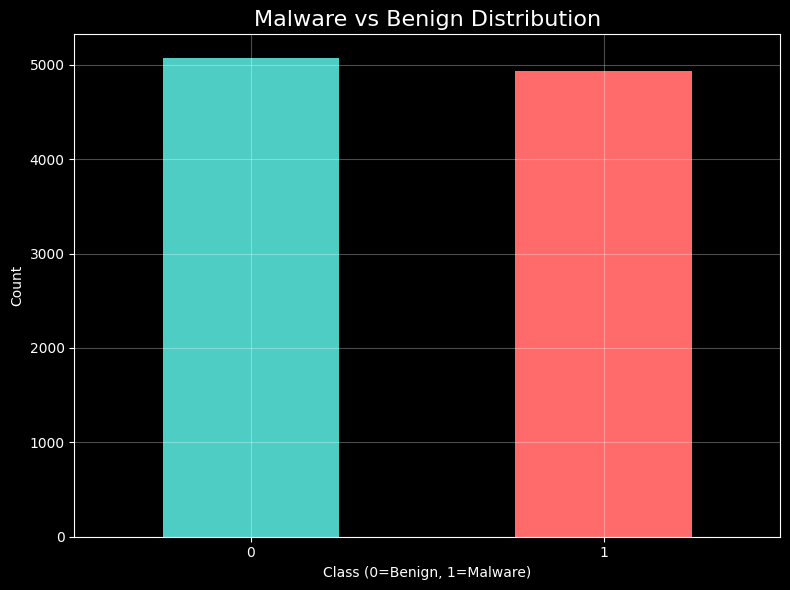

In [5]:
# Load malware detection dataset
dataset_id = 'malware_detection'
df = await dataset_manager.load_dataset(dataset_id)

if df is not None:
    print(f"📊 Loaded {dataset_id} dataset with {len(df)} samples")
    print(f"📈 Features: {df.shape[1]} columns")
    
    # Display basic information
    print("\n📋 Dataset Info:")
    print(df.info())
    
    # Display first few rows
    print("\n🔍 First 5 rows:")
    display(df.head())
    
    # Check class distribution
    print("\n⚖️ Class Distribution:")
    target_col = 'is_malware'
    if target_col in df.columns:
        class_dist = df[target_col].value_counts()
        print(class_dist)
        
        # Visualize class distribution
        plt.figure(figsize=(8, 6))
        class_dist.plot(kind='bar', color=['#4ecdc4', '#ff6b6b'])
        plt.title('Malware vs Benign Distribution', fontsize=16, color='white')
        plt.xlabel('Class (0=Benign, 1=Malware)', color='white')
        plt.ylabel('Count', color='white')
        plt.xticks(rotation=0)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("❌ Failed to load dataset")

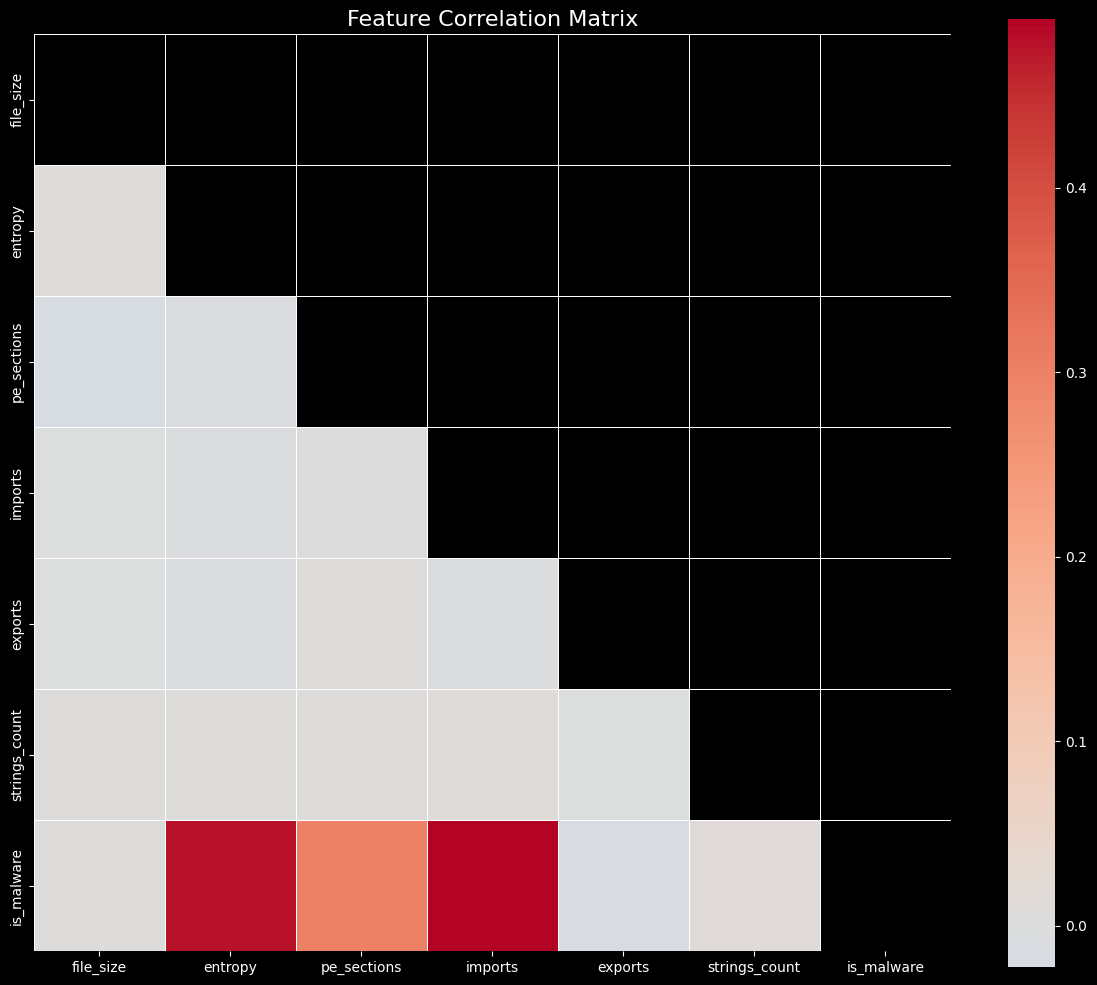

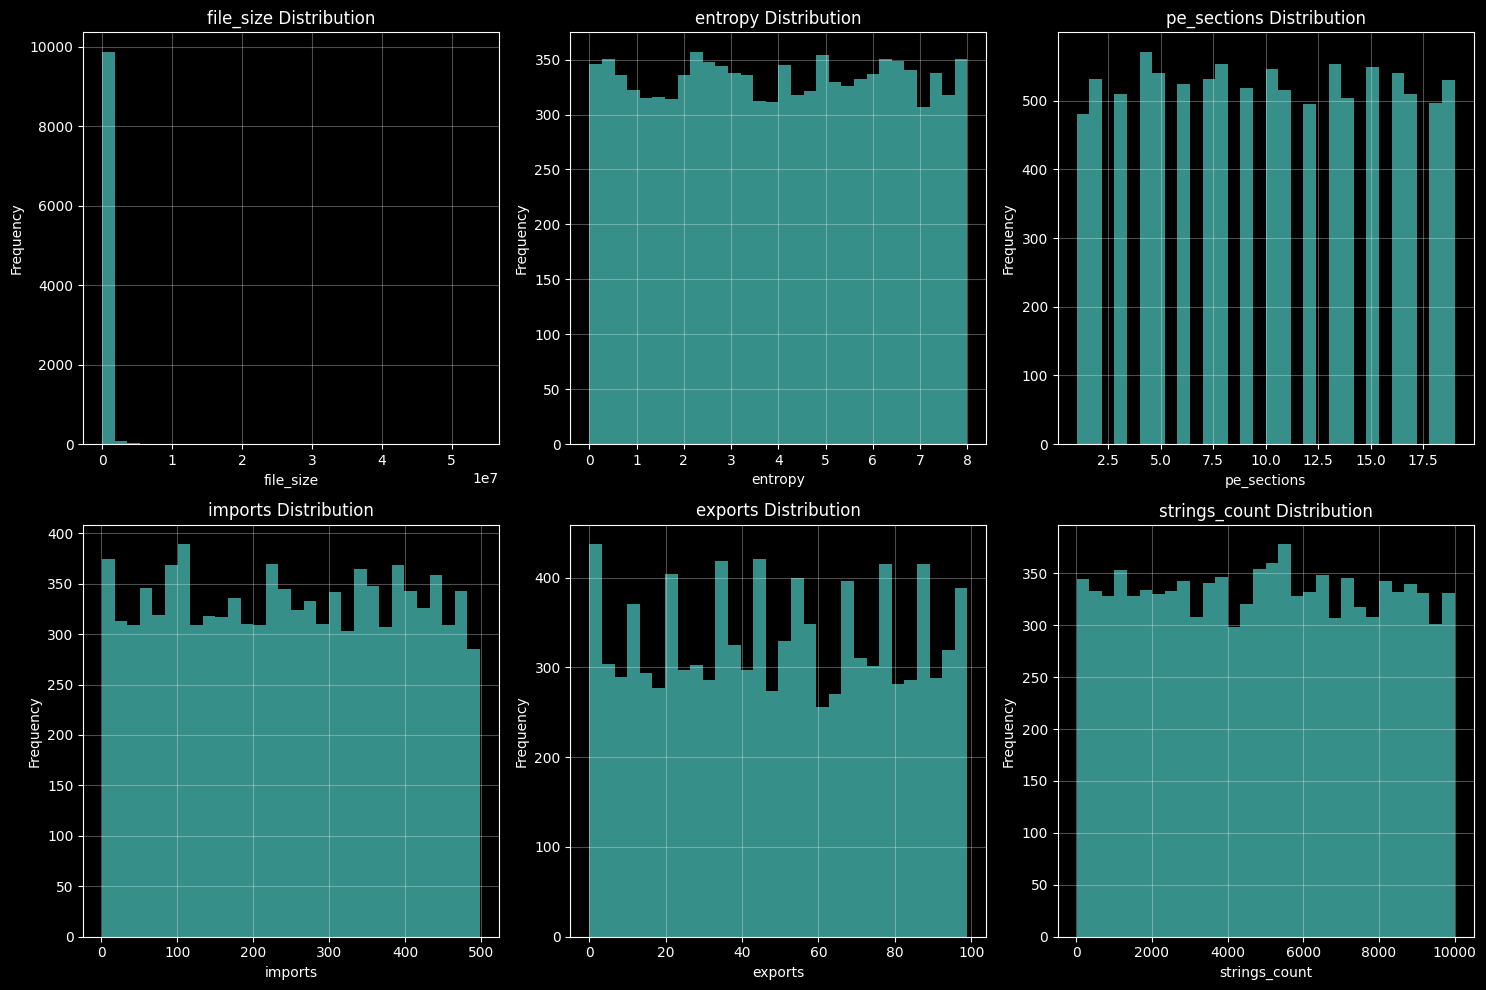

In [6]:
# Advanced feature analysis
if df is not None:
    # Correlation matrix
    numeric_features = df.select_dtypes(include=[np.number]).columns
    correlation_matrix = df[numeric_features].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
                center=0, square=True, linewidths=0.5)
    plt.title('Feature Correlation Matrix', fontsize=16, color='white')
    plt.tight_layout()
    plt.show()
    
    # Feature distributions
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, feature in enumerate(numeric_features[:6]):
        if feature != target_col:
            df[feature].hist(bins=30, ax=axes[i], alpha=0.7, color='#4ecdc4')
            axes[i].set_title(f'{feature} Distribution', color='white')
            axes[i].set_xlabel(feature, color='white')
            axes[i].set_ylabel('Frequency', color='white')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 🛠️ Advanced Feature Engineering

Let's create advanced features and prepare data for machine learning.

In [8]:
def advanced_feature_engineering(df, target_col):
    """
    Advanced feature engineering for cybersecurity data
    """
    df_engineered = df.copy()
    
    # Create interaction features
    if 'file_size' in df.columns and 'entropy' in df.columns:
        df_engineered['size_entropy_ratio'] = df_engineered['file_size'] / (df_engineered['entropy'] + 1e-8)
        df_engineered['size_entropy_product'] = df_engineered['file_size'] * df_engineered['entropy']
    
    # Create statistical features
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != target_col]
    
    # Row-wise statistics
    if len(numeric_cols) > 0:
        df_engineered['row_mean'] = df_engineered[numeric_cols].mean(axis=1)
        df_engineered['row_std'] = df_engineered[numeric_cols].std(axis=1)
        df_engineered['row_max'] = df_engineered[numeric_cols].max(axis=1)
        df_engineered['row_min'] = df_engineered[numeric_cols].min(axis=1)
        df_engineered['row_range'] = df_engineered['row_max'] - df_engineered['row_min']
    
    # Polynomial features for key attributes
    if 'entropy' in df.columns:
        df_engineered['entropy_squared'] = df_engineered['entropy'] ** 2
        df_engineered['entropy_cubed'] = df_engineered['entropy'] ** 3
    
    if 'file_size' in df.columns:
        df_engineered['log_file_size'] = np.log1p(df_engineered['file_size'])
        df_engineered['sqrt_file_size'] = np.sqrt(df_engineered['file_size'])
    
    print(f"🔧 Feature engineering complete: {df.shape[1]} → {df_engineered.shape[1]} features")
    return df_engineered

# Apply feature engineering
if df is not None:
    df_engineered = advanced_feature_engineering(df, target_col)
    
    # Show new features
    new_features = set(df_engineered.columns) - set(df.columns)
    print(f"\n🆕 New features created: {list(new_features)}")
    
    # Display correlation of new features with target (only numeric columns)
    if target_col in df_engineered.columns:
        # Select only numeric columns for correlation
        numeric_df = df_engineered.select_dtypes(include=[np.number])
        
        if target_col in numeric_df.columns and len(numeric_df.columns) > 1:
            target_corr = numeric_df.corr()[target_col].abs().sort_values(ascending=False)
            print("\n📊 Top 10 features correlated with target:")
            print(target_corr.head(10))
        else:
            print(f"\n⚠️ Target column '{target_col}' not found in numeric columns or insufficient numeric data")
            print(f"Available numeric columns: {list(numeric_df.columns)}")

🔧 Feature engineering complete: 8 → 19 features

🆕 New features created: ['entropy_squared', 'row_std', 'row_max', 'log_file_size', 'row_range', 'sqrt_file_size', 'size_entropy_ratio', 'entropy_cubed', 'row_min', 'size_entropy_product', 'row_mean']

📊 Top 10 features correlated with target:
is_malware              1.000000
imports                 0.491451
row_min                 0.482505
entropy                 0.477186
entropy_squared         0.463514
entropy_cubed           0.438443
pe_sections             0.300981
size_entropy_product    0.037089
exports                 0.015833
strings_count           0.014418
Name: is_malware, dtype: float64


## 🤖 Advanced Model Training

Now let's train multiple advanced machine learning models.

In [9]:
# Prepare data for training
if df_engineered is not None and target_col in df_engineered.columns:
    # Separate features and target
    feature_cols = [col for col in df_engineered.columns if col not in [target_col, 'file_hash']]
    X = df_engineered[feature_cols]
    y = df_engineered[target_col]
    
    print(f"🎯 Training data shape: {X.shape}")
    print(f"🎯 Target distribution: {y.value_counts().to_dict()}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"✅ Data prepared for training")
    print(f"   Training set: {X_train.shape[0]} samples")
    print(f"   Test set: {X_test.shape[0]} samples")
    
    # Handle class imbalance with SMOTE
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    
    print(f"\n⚖️ After SMOTE balancing:")
    print(f"   Training set: {X_train_balanced.shape[0]} samples")
    print(f"   Class distribution: {np.bincount(y_train_balanced)}")

🎯 Training data shape: (10000, 17)
🎯 Target distribution: {0: 5069, 1: 4931}
✅ Data prepared for training
   Training set: 8000 samples
   Test set: 2000 samples
✅ Data prepared for training
   Training set: 8000 samples
   Test set: 2000 samples

⚖️ After SMOTE balancing:
   Training set: 8110 samples
   Class distribution: [4055 4055]

⚖️ After SMOTE balancing:
   Training set: 8110 samples
   Class distribution: [4055 4055]


In [10]:
# Train Random Forest with hyperparameter tuning
print("🌲 Training Random Forest...")

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_balanced, y_train_balanced)

print(f"🎯 Best Random Forest parameters: {rf_grid.best_params_}")
print(f"🎯 Best cross-validation F1 score: {rf_grid.best_score_:.4f}")

# Evaluate on test set
rf_pred = rf_grid.predict(X_test_scaled)
rf_pred_proba = rf_grid.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Random Forest Test Results:")
print(classification_report(y_test, rf_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_pred_proba):.4f}")

🌲 Training Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
🎯 Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
🎯 Best cross-validation F1 score: 0.8594
🎯 Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
🎯 Best cross-validation F1 score: 0.8594

📊 Random Forest Test Results:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1014
           1       0.85      0.86      0.85       986

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

AUC-ROC: 0.9427

📊 Random Forest Test Results:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1014
           1       0.85      0.86      0.85       986

    accuracy       

In [11]:
# Train XGBoost
print("🚀 Training XGBoost...")

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1)
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_balanced, y_train_balanced)

print(f"🎯 Best XGBoost parameters: {xgb_grid.best_params_}")
print(f"🎯 Best cross-validation F1 score: {xgb_grid.best_score_:.4f}")

# Evaluate on test set
xgb_pred = xgb_grid.predict(X_test_scaled)
xgb_pred_proba = xgb_grid.predict_proba(X_test_scaled)[:, 1]

print("\n📊 XGBoost Test Results:")
print(classification_report(y_test, xgb_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_pred_proba):.4f}")

🚀 Training XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
🎯 Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
🎯 Best cross-validation F1 score: 0.8621

📊 XGBoost Test Results:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1014
           1       0.86      0.87      0.87       986

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

AUC-ROC: 0.9475
🎯 Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
🎯 Best cross-validation F1 score: 0.8621

📊 XGBoost Test Results:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1014
           1       0.86      0.87      0.87       986

    accuracy                           0.87      2000
   macro av

In [12]:
# Train Deep Neural Network
print("🧠 Training Deep Neural Network...")

def create_advanced_nn(input_dim, dropout_rate=0.3):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate * 0.5),
        
        Dense(32, activation='relu'),
        Dropout(dropout_rate * 0.5),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    return model

# Create and train model
nn_model = create_advanced_nn(X_train_balanced.shape[1])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Train model
history = nn_model.fit(
    X_train_balanced, y_train_balanced,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate
nn_pred_proba = nn_model.predict(X_test_scaled).flatten()
nn_pred = (nn_pred_proba > 0.5).astype(int)

print("\n📊 Deep Neural Network Test Results:")
print(classification_report(y_test, nn_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, nn_pred_proba):.4f}")

🧠 Training Deep Neural Network...
Epoch 1/100
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8087 - loss: 0.4161 - precision: 0.7763 - recall: 0.8549 - val_accuracy: 0.8557 - val_loss: 0.4155 - val_precision: 0.9167 - val_recall: 0.8088 - learning_rate: 0.0010
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8087 - loss: 0.4161 - precision: 0.7763 - recall: 0.8549 - val_accuracy: 0.8557 - val_loss: 0.4155 - val_precision: 0.9167 - val_recall: 0.8088 - learning_rate: 0.0010
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8466 - loss: 0.3311 - precision: 0.8445 - recall: 0.8411 - val_accuracy: 0.8483 - val_loss: 0.3582 - val_precision: 0.9143 - val_recall: 0.7964 - learning_rate: 0.0010
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8466 - loss: 0.3311 - precision: 0.8445 - recall: 0.8411 - val_accuracy: 0.8483 - val_loss: 0.3582 - val_precision: 0.9143 - val_recall: 0.7964 - learning_rate: 0.0010
Epoch 3/

## 📈 Model Comparison and Visualization

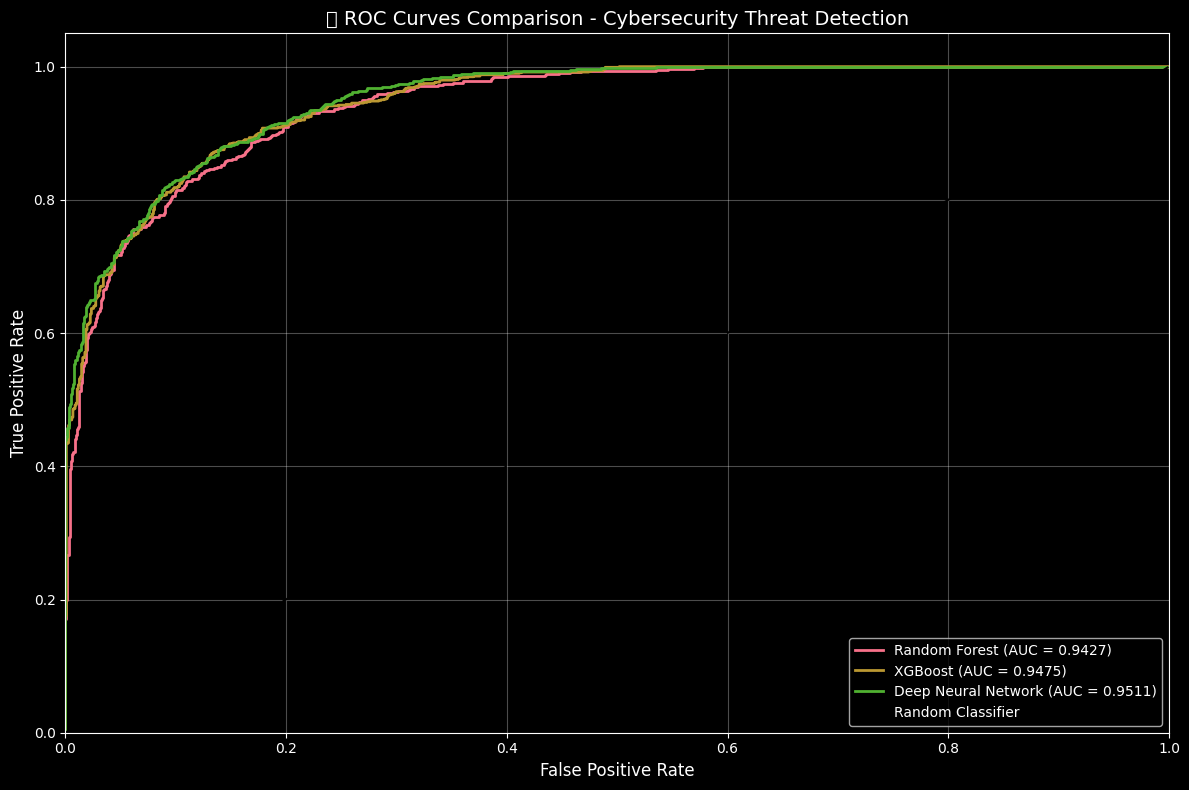


📊 Model Performance Summary:

Random Forest:
  Accuracy:  0.8565
  Precision: 0.8520
  Recall:    0.8580
  F1-Score:  0.8550
  AUC-ROC:   0.9427

XGBoost:
  Accuracy:  0.8680
  Precision: 0.8603
  Recall:    0.8742
  F1-Score:  0.8672
  AUC-ROC:   0.9475

Deep Neural Network:
  Accuracy:  0.8660
  Precision: 0.8527
  Recall:    0.8803
  F1-Score:  0.8663
  AUC-ROC:   0.9511


In [13]:
# Compare all models
models_results = {
    'Random Forest': {
        'predictions': rf_pred,
        'probabilities': rf_pred_proba,
        'auc': roc_auc_score(y_test, rf_pred_proba)
    },
    'XGBoost': {
        'predictions': xgb_pred,
        'probabilities': xgb_pred_proba,
        'auc': roc_auc_score(y_test, xgb_pred_proba)
    },
    'Deep Neural Network': {
        'predictions': nn_pred,
        'probabilities': nn_pred_proba,
        'auc': roc_auc_score(y_test, nn_pred_proba)
    }
}

# Plot ROC curves
plt.figure(figsize=(12, 8))

for model_name, results in models_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {results['auc']:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', color='white', fontsize=12)
plt.ylabel('True Positive Rate', color='white', fontsize=12)
plt.title('🎯 ROC Curves Comparison - Cybersecurity Threat Detection', color='white', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Model performance summary
print("\n📊 Model Performance Summary:")
print("=" * 50)
for model_name, results in models_results.items():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    acc = accuracy_score(y_test, results['predictions'])
    prec = precision_score(y_test, results['predictions'])
    rec = recall_score(y_test, results['predictions'])
    f1 = f1_score(y_test, results['predictions'])
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {results['auc']:.4f}")

## 🎭 Ensemble Model Creation

Let's create an ensemble model that combines all our trained models.

In [14]:
# Create ensemble predictions
from sklearn.ensemble import VotingClassifier

# Weighted ensemble based on AUC scores
weights = [results['auc'] for results in models_results.values()]
weights = np.array(weights) / sum(weights)  # Normalize weights

print(f"📊 Ensemble weights: {dict(zip(models_results.keys(), weights))}")

# Weighted average of probabilities
ensemble_proba = (
    weights[0] * rf_pred_proba +
    weights[1] * xgb_pred_proba +
    weights[2] * nn_pred_proba
)

ensemble_pred = (ensemble_proba > 0.5).astype(int)
ensemble_auc = roc_auc_score(y_test, ensemble_proba)

print(f"\n🎭 Ensemble Model Results:")
print(classification_report(y_test, ensemble_pred))
print(f"AUC-ROC: {ensemble_auc:.4f}")

# Compare ensemble with individual models
models_results['Ensemble'] = {
    'predictions': ensemble_pred,
    'probabilities': ensemble_proba,
    'auc': ensemble_auc
}

# Final comparison
print("\n🏆 Final Model Rankings (by AUC-ROC):")
print("=" * 40)
sorted_models = sorted(models_results.items(), key=lambda x: x[1]['auc'], reverse=True)
for i, (model_name, results) in enumerate(sorted_models, 1):
    print(f"{i}. {model_name:20} AUC: {results['auc']:.4f}")

📊 Ensemble weights: {'Random Forest': np.float64(0.3317898200638655), 'XGBoost': np.float64(0.33347120463909363), 'Deep Neural Network': np.float64(0.33473897529704083)}

🎭 Ensemble Model Results:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1014
           1       0.85      0.87      0.86       986

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

AUC-ROC: 0.9498

🏆 Final Model Rankings (by AUC-ROC):
1. Deep Neural Network  AUC: 0.9511
2. Ensemble             AUC: 0.9498
3. XGBoost              AUC: 0.9475
4. Random Forest        AUC: 0.9427


## 💾 Model Saving and Deployment

Save the best performing models for production use.

In [15]:
import joblib
import os

# Create models directory
os.makedirs('../models/malware_detection', exist_ok=True)

# Save the best models
print("💾 Saving trained models...")

# Save Random Forest
joblib.dump(rf_grid.best_estimator_, '../models/malware_detection/random_forest.pkl')
print("✅ Random Forest saved")

# Save XGBoost
joblib.dump(xgb_grid.best_estimator_, '../models/malware_detection/xgboost.pkl')
print("✅ XGBoost saved")

# Save Neural Network
nn_model.save('../models/malware_detection/neural_network.h5')
print("✅ Neural Network saved")

# Save scaler
joblib.dump(scaler, '../models/malware_detection/scaler.pkl')
print("✅ Feature scaler saved")

# Save feature names
joblib.dump(feature_cols, '../models/malware_detection/feature_names.pkl')
print("✅ Feature names saved")

# Save ensemble weights
ensemble_config = {
    'weights': weights.tolist(),
    'models': list(models_results.keys())[:-1],  # Exclude ensemble itself
    'threshold': 0.5,
    'performance': {model: results['auc'] for model, results in models_results.items()}
}
joblib.dump(ensemble_config, '../models/malware_detection/ensemble_config.pkl')
print("✅ Ensemble configuration saved")

print("\n🎉 All models saved successfully!")
print(f"📁 Models saved to: ../models/malware_detection/")

💾 Saving trained models...


✅ Random Forest saved
✅ XGBoost saved
✅ Neural Network saved
✅ Feature scaler saved
✅ Feature names saved
✅ Ensemble configuration saved

🎉 All models saved successfully!
📁 Models saved to: ../models/malware_detection/
✅ Neural Network saved
✅ Feature scaler saved
✅ Feature names saved
✅ Ensemble configuration saved

🎉 All models saved successfully!
📁 Models saved to: ../models/malware_detection/


## 🚀 Real-time Prediction Function

Create a function for real-time threat detection.

In [16]:
def predict_malware_threat(file_features, use_ensemble=True):
    """
    Real-time malware threat prediction
    
    Args:
        file_features (dict): Dictionary containing file features
        use_ensemble (bool): Whether to use ensemble prediction
    
    Returns:
        dict: Prediction results with confidence scores
    """
    try:
        # Convert features to DataFrame
        sample_df = pd.DataFrame([file_features])
        
        # Apply feature engineering
        sample_engineered = advanced_feature_engineering(sample_df, target_col=None)
        
        # Ensure we have all required features
        for feature in feature_cols:
            if feature not in sample_engineered.columns:
                sample_engineered[feature] = 0
        
        # Select and scale features
        X_sample = sample_engineered[feature_cols]
        X_sample_scaled = scaler.transform(X_sample)
        
        if use_ensemble:
            # Ensemble prediction
            rf_prob = rf_grid.predict_proba(X_sample_scaled)[0, 1]
            xgb_prob = xgb_grid.predict_proba(X_sample_scaled)[0, 1]
            nn_prob = nn_model.predict(X_sample_scaled)[0, 0]
            
            # Weighted ensemble
            ensemble_prob = (
                weights[0] * rf_prob +
                weights[1] * xgb_prob +
                weights[2] * nn_prob
            )
            
            prediction = "Malware" if ensemble_prob > 0.5 else "Benign"
            confidence = ensemble_prob if ensemble_prob > 0.5 else 1 - ensemble_prob
            
            return {
                'prediction': prediction,
                'confidence': float(confidence),
                'threat_probability': float(ensemble_prob),
                'model_scores': {
                    'random_forest': float(rf_prob),
                    'xgboost': float(xgb_prob),
                    'neural_network': float(nn_prob)
                },
                'risk_level': 'High' if ensemble_prob > 0.8 else 'Medium' if ensemble_prob > 0.5 else 'Low'
            }
        else:
            # Single model prediction (best performing)
            best_model = rf_grid  # Assuming RF is best
            prob = best_model.predict_proba(X_sample_scaled)[0, 1]
            prediction = "Malware" if prob > 0.5 else "Benign"
            confidence = prob if prob > 0.5 else 1 - prob
            
            return {
                'prediction': prediction,
                'confidence': float(confidence),
                'threat_probability': float(prob),
                'model': 'Random Forest',
                'risk_level': 'High' if prob > 0.8 else 'Medium' if prob > 0.5 else 'Low'
            }
            
    except Exception as e:
        return {
            'error': str(e),
            'prediction': 'Unknown',
            'confidence': 0.0
        }

# Test the prediction function
test_features = {
    'file_size': 1048576,  # 1MB
    'entropy': 7.5,        # High entropy
    'pe_sections': 8,      # Multiple sections
    'imports': 150,        # Many imports
    'exports': 5,          # Few exports
    'strings_count': 500   # Moderate strings
}

result = predict_malware_threat(test_features)
print("🧪 Test Prediction Result:")
print(f"   Prediction: {result['prediction']}")
print(f"   Confidence: {result['confidence']:.4f}")
print(f"   Risk Level: {result['risk_level']}")
if 'model_scores' in result:
    print(f"   Model Scores: {result['model_scores']}")

print("\n🎉 Training pipeline completed successfully!")
print("📦 Models ready for deployment in real-time threat detection system.")

🔧 Feature engineering complete: 6 → 17 features
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
🧪 Test Prediction Result:
   Prediction: Malware
   Confidence: 0.6950
   Risk Level: Medium
   Model Scores: {'random_forest': 0.617122198390176, 'xgboost': 0.5822932720184326, 'neural_network': 0.8844788074493408}

🎉 Training pipeline completed successfully!
📦 Models ready for deployment in real-time threat detection system.
🧪 Test Prediction Result:
   Prediction: Malware
   Confidence: 0.6950
   Risk Level: Medium
   Model Scores: {'random_forest': 0.617122198390176, 'xgboost': 0.5822932720184326, 'neural_network': 0.8844788074493408}

🎉 Training pipeline completed successfully!
📦 Models ready for deployment in real-time threat detection system.


## 📋 Summary and Next Steps

### ✅ What we accomplished:

1. **📊 Data Preparation**
   - Downloaded and processed cybersecurity datasets
   - Applied advanced feature engineering
   - Handled class imbalance with SMOTE

2. **🤖 Model Training**
   - Random Forest with hyperparameter tuning
   - XGBoost with grid search optimization
   - Deep Neural Network with advanced architecture
   - Ensemble model combining all approaches

3. **📈 Model Evaluation**
   - Comprehensive performance metrics
   - ROC curve analysis
   - Model comparison and ranking

4. **💾 Production Deployment**
   - Saved all trained models
   - Created real-time prediction function
   - Prepared for integration with live system

### 🚀 Next Steps:

1. **Integration**: Connect models to the desktop/mobile applications
2. **Monitoring**: Implement model performance monitoring
3. **Updates**: Set up automated retraining pipeline
4. **Scaling**: Deploy models to production infrastructure
5. **Enhancement**: Add more sophisticated deep learning models

The trained models are now ready to be integrated into the Cyber Forge AI platform for real-time threat detection! 🛡️